<a href="https://colab.research.google.com/github/humairaafreen17-ship-it/wildrydes-site/blob/main/Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class Car:
    def __init__(self, date, model, company, type, rating, price, mileage):
        self.unique_id = id(self)  # Unique Identifier using memory id
        self.date = date           # Manufactured date
        self.model = model         # Car's model name
        self.company = company     # Company/Manufacturer name
        self.type = type           # Car's type (Electric or Non-Electric)
        self.rating = rating       # Car's rating on the auction website
        self.price = price         # Car's price in USD
        self.mileage = mileage     # Car's mileage in miles

    def __str__(self):
        return f"{self.unique_id},{self.date},{self.model},{self.company},{self.type},{self.rating},{self.price},{self.mileage}"


# Subclass for Electric Cars
class ElectricCar(Car):
    def __init__(self, date, model, company, rating, price, mileage):
        super().__init__(date, model, company, "Electric", rating, price, mileage)


# Subclass for Non-Electric Cars
class NonElectricCar(Car):
    def __init__(self, date, model, company, rating, price, mileage):
        super().__init__(date, model, company, "NonElectric", rating, price, mileage)


# Tesla subclass inheriting from ElectricCar
class Tesla(ElectricCar):
    def __init__(self, date, model, rating, price, mileage):
        super().__init__(date, model, "Tesla", rating, price, mileage)


# Ford subclass inheriting from NonElectricCar
class Ford(NonElectricCar):
    def __init__(self, date, model, rating, price, mileage):
        super().__init__(date, model, "Ford", rating, price, mileage)


# BMW subclass inheriting from NonElectricCar
class BMW(NonElectricCar):
    def __init__(self, date, model, rating, price, mileage):
        super().__init__(date, model, "BMW", rating, price, mileage)


# Example Usage
tesla_car = Tesla("2023-06-15", "Model S", 4.8, 75000, 15000)
ford_car = Ford("2021-09-10", "Mustang", 4.6, 55000, 20000)
bmw_car = BMW("2022-03-20", "X5", 4.7, 65000, 18000)
FordCar = Ford("2024-11-15","Mustang", 2, 641, 86.06)



print(tesla_car)
print(str(ford_car))
print(str(bmw_car))
print(str(FordCar))


132358921925776,2023-06-15,Model S,Tesla,Electric,4.8,75000,15000
132358921925392,2021-09-10,Mustang,Ford,NonElectric,4.6,55000,20000
132358921925200,2022-03-20,X5,BMW,NonElectric,4.7,65000,18000
132358921925008,2024-11-15,Mustang,Ford,NonElectric,2,641,86.06


In [ ]:
import pickle
import csv
# we only need the following line if running it outside Colab where code may be in separate python files
# from carHierarchy import Car, ElectricCar, NonElectricCar, Tesla, Ford, BMW


# Define the file names
CSV_FILENAME = "cars.csv"
DAT_FILENAME = "cars.dat"
CSV_HEADERS = ["unique_id", "date", "model", "company", "type", "rating", "price", "mileage"]

# Load the .dat file
with open(DAT_FILENAME, "rb") as file:
    data = pickle.load(file)  # Load the pickled data

# We now check what kind of object was loaded.
# If it's a dictionary, we assume the values are the Car objects we care about.
# If it's already a list, we can use it directly.
if isinstance(data, dict):
    objects = list(data.values())
else:
    objects = data


# Now we open the CSV file in write mode, making sure to use newline='' to avoid any potential blank lines between rows
# Then we create a CSV writer object to handle writing our data.
# We create the header row
# Now we loop through every object we pulled from the pickle file
# Each object is converted to a string (using the __str__ method defined in the Car class)
# We split that string on commas so it's in list format, then write it as a row in the CSV
with open(CSV_FILENAME, mode="w", newline="") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(CSV_HEADERS)

    for obj in objects:
        writer.writerow(str(obj).split(","))

print(f"CSV file '{CSV_FILENAME}' has been created successfully!")


CSV file 'cars.csv' has been created successfully!


**Introduction**

The dataset contains information on 12,000 used vehicles, each uniquely identified by a unique_id. It includes a variety of attributes that describe the vehicle’s specifications and condition. The data is structured across eight columns, which fall into four primary categories:

**Categorical Data:**

model: The specific model of the vehicle (e.g., Model S, Model Y).

company: The manufacturer or brand of the vehicle (e.g., Tesla).

type: The type of vehicle (e.g., Electric/Non Electric).

**Quantitative (Numerical) Data:**

rating: A consumer or quality rating for the vehicle, represented as an integer (1-5).

price: The price of the vehicle in dollars, stored as a float.

mileage: The total distance the vehicle has traveled, measured in miles.

**Date Data:**

date: The listing or acquisition date for the vehicle, stored as a string in date format (e.g., "2024-10-28").

**Identifier:**

unique_id: A unique numeric identifier for each vehicle entry.

In [ ]:
import csv


# Hardcoded definitions of what we consider each type of data
# Since they are assumed constants, write that as all caps
# Categorical column values that are empty will be replaced with the mode value of the column
# Quantitative column values that are empty will be replaced with the average value of the column
# Date column values that are empty will be replaced with a value based on the amount of miles in that row
CATEGORICAL_COLUMNS = ['model', 'company', 'type']
QUANTITATIVE_COLUMNS = ['rating', 'price', 'mileage']
DATE_COLUMNS = ['date']

INPUT_FILE = 'cars.csv'
OUTPUT_FILE = 'cars_cleaned.csv'

#We open the input file and store all the rows in an empty list we create called rows
#We also store the headers in another list called headers
with open(INPUT_FILE, mode='r', newline='') as infile:
    reader = csv.DictReader(infile)
    rows = []
    for row in reader:
        rows.append(row)
    headers = reader.fieldnames

# Let's create an empty dictionary called columnValues
# Then we're going to store the different column headers in it
# We skip unique_id because it always contains a value and if it didn't thats a pretty big problem
# Also we don't want to set unique_id to either an average OR the mode, as it should be unique
columnValues = {}
for col in headers:
    if col != 'unique_id':
        columnValues[col] = []

# Here we go through all the rows one by one.
# For each row, we also iterate through each column we're interested in, so this is a nested loop.
# We use .strip() to remove any leading or trailing whitespace from the value (e.g., " Ford " → "Ford").
# If the cleaned value is empty, we skip it—nothing to process.
# If the column is in QUANTITATIVE_COLUMNS, we convert the value from a string to a decimal number (float),
# and then store it in our dictionary (column_values) for later averaging.
# If it's not quantitative (i.e., assumed to be categorical), we just store the string as-is.
# In short: this section gathers all valid, non-empty values into memory so we can later calculate the mean or mode for each column.
for row in rows:
    for col in columnValues:
        value = row[col].strip()
        if value != "":
            if col in QUANTITATIVE_COLUMNS:
                try:
                    columnValues[col].append(float(value))
                except ValueError:
                    pass
            else:
                columnValues[col].append(value)

# fillValues is a dictionary that is going to store the mean or mode for each column
fillValues = {}

# For each of the quantitative columns (rating, price, mileage), we want to calculate the average (mean).
# First, we set up a running total and a count for how many valid values we’ve seen.
# We go through each value for that column and add it to the total, increasing the count each time.
# After looping through all values, we check if the count is greater than 0 (to avoid division by zero).
# If so, we calculate the average by dividing total by count, and round it to 2 decimal places.
# If the count is 0 (i.e., all values were missing or invalid), we just use 0 as the fallback average (with the data we have, it can't happen but doesn't hurt to have)
# There's probably a library that does counting and averages for us but we're unsure what libraries we can and can't import, so we do it live.
# Finally, we store this average in a dictionary (fillValues) under the name of the column
# So we can later use it to fill in any blank values for that column.
for col in QUANTITATIVE_COLUMNS:
    total = 0
    count = 0
    for val in columnValues[col]:
        total += val
        count += 1
    if count > 0:
        average = round(total / count, 2)
    else:
        average = 0
    # Here we round ratings, the average comes out to something like 3.96 but we want to return to an integer value as they were initially provided as integers
    if col == 'rating':
        fillValues[col] = round(average)
    else:
        fillValues[col] = average
    # Debug output
    print(f"[{col.upper()}] Count: {count}, Total: {total}, Average Stored: {average}")

# For each of the categorical columns (like model, company, type), we want to calculate the mode (most frequent value).
# We create a frequency dictionary to count how many times each unique value appears.
# We loop through the collected non-empty values and increment the count for each one.
# Then we search the frequency dictionary to find the value with the highest count.
# If there's at least one value, we store that most common one in fillValues[col].
# If all values were missing, we use "Unknown" as a fallback (again, not possible with our current dataset, but doesn't hurt to have)
for col in CATEGORICAL_COLUMNS:
    frequency = {}
    for val in columnValues[col]:
        if val in frequency:
            frequency[val] += 1
        else:
            frequency[val] = 1

    mostCommon = None
    mostCommonCount = 0
    for item, count in frequency.items():
        if count > mostCommonCount:
            mostCommon = item
            mostCommonCount = count

    # ternary operator to be fancy
    # stores mostCommon in finalValue if its not empty, otherwise stores "Unknown"
    # the following block is the simpler way to write it
    '''
    if mostCommon is not None:
        finalValue = mostCommon
    else:
        finalValue = "Unknown"
    '''
    finalValue = mostCommon if mostCommon is not None else "Unknown"
    fillValues[col] = finalValue

    # Debug output
    print(f"[{col.upper()}] Frequencies: {frequency}")
    print(f"[{col.upper()}] Most Common: {finalValue} (Count: {mostCommonCount})")




# For each date column (in this case just 'date'), we replace missing values based on the mileage
# The higher the mileage, the earlier in the year the car was likely manufactured
# Mileage ranges from 60,000 (newest) to 99,999 (oldest), and we map that to arbritrary anchor dates
for col in DATE_COLUMNS:
    for row in rows:
        if row[col].strip() == "":
            mileage_str = row['mileage']
            try:
                mileage = float(mileage_str)
            except:
                # Only happens when mileage is blank
                row[col] = "12-01-2024"
                continue

            if mileage >= 90000:
                row[col] = "01-01-2024"
            elif mileage >= 80000:
                row[col] = "03-01-2024"
            elif mileage >= 70000:
                row[col] = "06-01-2024"
            elif mileage >= 60000:
                row[col] = "09-01-2024"
            else:
                # Won't ever occur in the current dataset as the current dataset starts at 60000 miles
                row[col] = "12-01-2024"


# Just like above, we go through each row and column
# If we find an empty cell, we fill it with the value we derived above that matches the column and convert it to a string
for row in rows:
    for col in fillValues:
        if row[col].strip() == "":
            row[col] = str(fillValues[col])

# Write final output
with open(OUTPUT_FILE, mode='w', newline='') as outfile:
    writer = csv.DictWriter(outfile, fieldnames=headers)
    writer.writeheader()
    for row in rows:
        writer.writerow(row)

print(f"Done. Cleaned CSV written to '{OUTPUT_FILE}'.")





[RATING] Count: 11548, Total: 45698.0, Average Stored: 3.96
[PRICE] Count: 11048, Total: 183092160.0, Average Stored: 16572.43
[MILEAGE] Count: 11048, Total: 834574766.6799988, Average Stored: 75540.8
[MODEL] Frequencies: {'Model S': 2641, 'Model Y': 2832, 'Model X': 380, 'Explorer': 2616, 'Mustang': 2390, 'F150': 352, 'X3': 387, 'X5': 345, 'X7': 57}
[MODEL] Most Common: Model Y (Count: 2832)
[COMPANY] Frequencies: {'Tesla': 5853, 'Ford': 5358, 'BMW': 789}
[COMPANY] Most Common: Tesla (Count: 5853)
[TYPE] Frequencies: {'Electric': 5853, 'non-Electric': 6147}
[TYPE] Most Common: non-Electric (Count: 6147)
Done. Cleaned CSV written to 'cars_cleaned.csv'.


**How we dealt with missing values**

Quantitative columns (rating, price, mileage):
Missing values were replaced with the average (mean) of the non-missing values for each column. For rating, this average was also rounded to the nearest integer to preserve its original data type.

Categorical columns (model, company, type):
Missing values were filled with the mode (the most frequent value) for each column. If no mode could be found (e.g., all values missing), the fallback value "Unknown" was used.

Date column (date):
Missing dates were imputed based on the mileage value in that row, with higher mileage corresponding to earlier assumed manufacture dates. This heuristic mapped mileage ranges to preset dates in 2024.

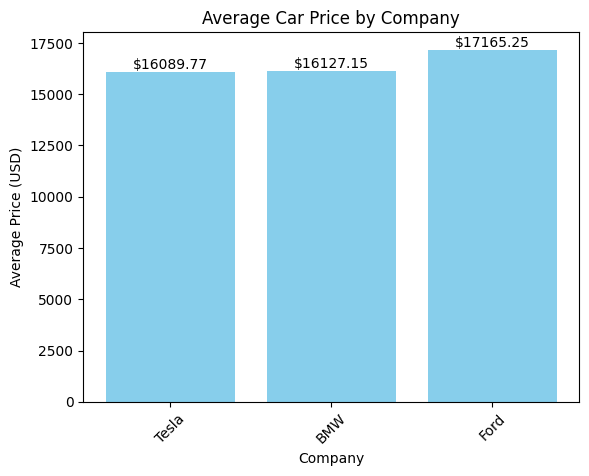

In [ ]:
import csv
import matplotlib.pyplot as plt

# Read the CSV file manually
data = {}
with open("cars_cleaned.csv", "r") as file:
    reader = csv.reader(file)
    headers = next(reader)  # Skip the header row

    for row in reader:
        company = row[3]  # Company column
        price_str = row[6].strip()  # Remove whitespace

        # Skip rows where price is empty
        # Redundant since we
        if price_str == "":
            continue

        try:
            price = float(price_str)  # Convert to float
        except ValueError:
            continue  # Skip invalid data

        if company in data:
            data[company].append(price)
        else:
            data[company] = [price]

# Calculate the average price per company
avg_prices = {company: sum(prices) / len(prices) for company, prices in data.items() if prices}

# Sort data for better visualization
sorted_companies = sorted(avg_prices, key=avg_prices.get)
sorted_prices = [avg_prices[company] for company in sorted_companies]

# Create the bar chart
plt.bar(sorted_companies, sorted_prices, color="skyblue")

# Formatting and adding labels
def add_labels(prices):
    for i, price in enumerate(prices):
        plt.text(i, price, f"${price:.2f}", ha='center', va='bottom')

add_labels(sorted_prices)

plt.title("Average Car Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)

# Show the chart
plt.savefig("bar_chart.png", dpi=300)
plt.show()




The bar chart shows that the average car prices for Tesla, BMW, and Ford are relatively similar, all hovering around the $16,000–$17,000 range. Despite Tesla selling electric vehicles only, its average price aligns closely with that of BMW, a traditionally premium internal combustion brand. This could be partially influenced by factors such as government subsidies or a smaller model range. Although not shown in the chart itself, if sales volume data indicates that Tesla has fewer listings than Ford or BMW, that may also affect its average price, as smaller sample sizes can be more sensitive to price variation.

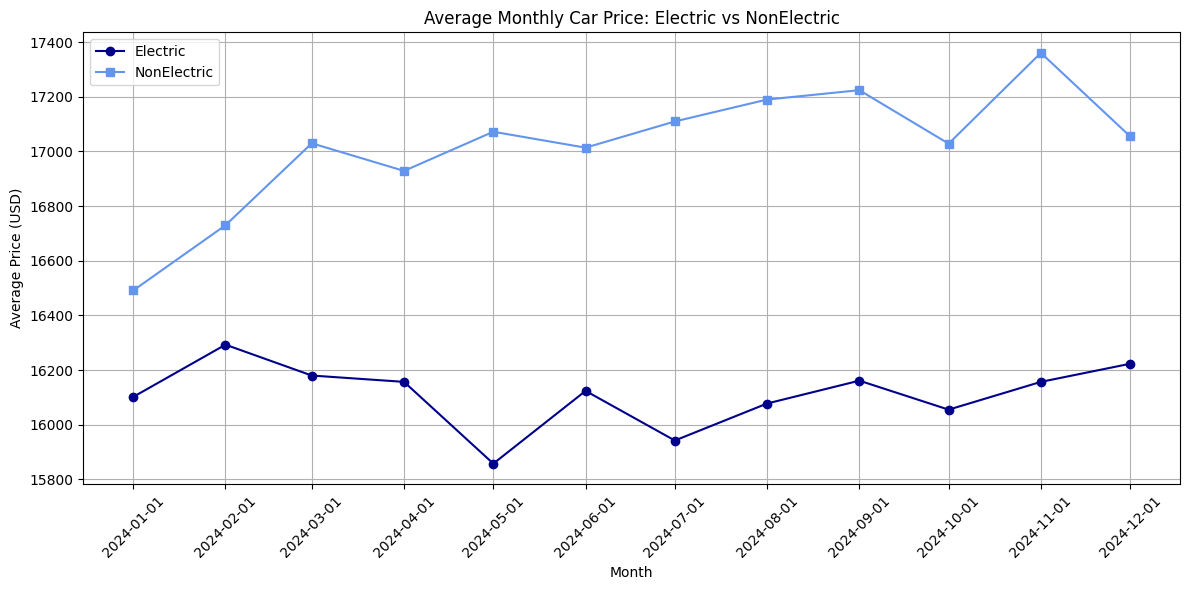

In [ ]:
##linegraph - cost by type

import csv
import matplotlib.pyplot as plt
from datetime import datetime

# Step 1: Group prices by (month, type) using flat dictionary with tuple keys
grouped_data = {}

with open("cars_cleaned.csv", "r") as file:
    reader = csv.reader(file)
    headers = next(reader)

    for row in reader:
        try:
            date_str = row[1].strip()
            car_type = row[4].strip().replace("-", "").title()
            price = float(row[6].strip())

            date = datetime.strptime(date_str, "%Y-%m-%d").date()
            month = date.replace(day=1)  # Normalize to first of month

            key = (month, car_type)

            if key not in grouped_data:
                grouped_data[key] = []
            grouped_data[key].append(price)

        except (ValueError, IndexError):
            continue

# Step 2: Collect unique months and calculate average prices
all_months = []
electric_avg = []
nonelectric_avg = []

for key in grouped_data:
    month = key[0]
    if month not in all_months:
        all_months.append(month)

all_months.sort()

for month in all_months:
    electric_key = (month, "Electric")
    nonelectric_key = (month, "Nonelectric")

    if electric_key in grouped_data:
        prices = grouped_data[electric_key]
        electric_avg.append(sum(prices) / len(prices))
    else:
        electric_avg.append(None)

    if nonelectric_key in grouped_data:
        prices = grouped_data[nonelectric_key]
        nonelectric_avg.append(sum(prices) / len(prices))
    else:
        nonelectric_avg.append(None)

# Step 3: Plot
plt.figure(figsize=(12, 6))
plt.plot(all_months, electric_avg, label="Electric", marker="o", color="darkblue")
plt.plot(all_months, nonelectric_avg, label="NonElectric", marker="s", color="cornflowerblue")

plt.title("Average Monthly Car Price: Electric vs NonElectric")
plt.xlabel("Month")
plt.ylabel("Average Price (USD)")
plt.legend()
plt.grid(True)
plt.xticks(all_months, rotation=45)
plt.tight_layout()
plt.savefig("line_graph.png", dpi=300)
plt.show()

The graph illustrates the average monthly car prices for Electric and Non-Electric vehicles throughout 2024. Overall, Non-Electric cars consistently maintained a higher average price than Electric cars across all months. Non-Electric vehicle prices showed a general upward trend, peaking in November before slightly declining in December. In contrast, Electric car prices were relatively more stable, fluctuating mildly but remaining in a tighter range. Notably, Electric car prices dipped in May and July but rebounded afterward. The consistent price gap between the two categories suggests that Non-Electric vehicles remained more expensive on average, possibly due to differences in demand, production costs, or features.

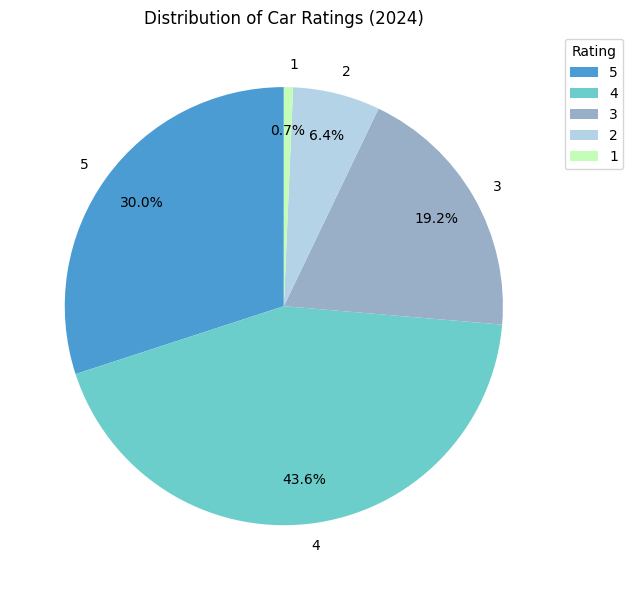

In [ ]:
##pie chart
import csv
import matplotlib.pyplot as plt

# Initialize dictionary to count ratings
rating_counts = {}

# Open and read the CSV file
with open("cars_cleaned.csv", "r") as file:
    reader = csv.reader(file)
    headers = next(reader)  # Skip header row

    # Find the index of the 'rating' column
    for i in range(len(headers)):
        if headers[i].lower() == "rating":
            rating_index = i
            break

    # Count each rating occurrence
    for row in reader:
        rating = row[rating_index]
        if rating in rating_counts:
            rating_counts[rating] += 1
        else:
            rating_counts[rating] = 1

# Prepare labels and sizes for the pie chart
labels = []
sizes = []

sorted_keys = list(rating_counts.keys())

for i in range(len(sorted_keys)):
    sorted_keys[i] = int(sorted_keys[i])

sorted_keys.sort(reverse=True)

for key in sorted_keys:
    key_str = str(key)
    labels.append(key_str)
    sizes.append(rating_counts[key_str])


# Plot the pie chart
custom_colors = ["#4B9CD3", "#6CCECB", "#98AFC7","#B5D3E7", "#C3FDB8"]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=custom_colors, labeldistance=1.1, pctdistance=0.8)
plt.title("Distribution of Car Ratings (2024)")
plt.tight_layout()
plt.legend(title="Rating", loc="upper left", bbox_to_anchor=(1, 1))
plt.savefig("pie_chart.png", dpi=300)
plt.show()



This pie chart shows the distribution of car ratings for the 12,000 vehicles in the dataset. A rating of "4" makes up the majority, which may be influenced by how missing values were handled. Specifically, missing entries in the Car Ratings column were filled with the mean rating (approximately 3.96), which rounds to 4. This data-cleaning step likely increased the proportion of "4" ratings. Even so, most ratings fall between "3" and "5", suggesting that car buyers tend to report relatively high satisfaction, potentially because they research extensively before making such a significant purchase.

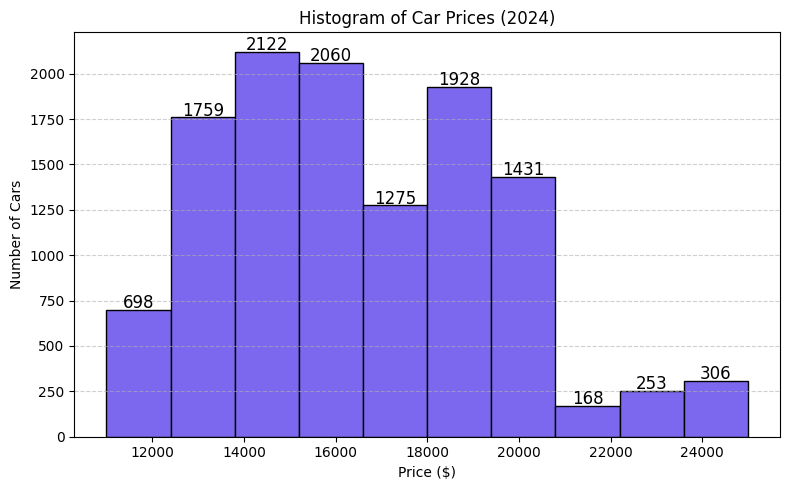

In [ ]:
#histogram

import csv
import matplotlib.pyplot as plt

# Initialize list to store price values
price_values = []

# Open and read the CSV file
with open("cars_cleaned.csv", "r") as file:
    reader = csv.reader(file)
    headers = next(reader)  # Skip header row

    # Find the index of the 'price' column
    for i in range(len(headers)):
        if headers[i].lower() == "price":
            price_index = i
            break

    # Collect valid price values
    for row in reader:
        try:
            price = float(row[price_index])
            price_values.append(price)
        except ValueError:
            continue  # Skip rows with missing or non-numeric price

# Plot the histogram
# Plot the histogram and get the bar container
plt.figure(figsize=(8, 5))
counts, bins, bars = plt.hist(price_values, bins=10, edgecolor='black', color="mediumslateblue")
for bar in bars:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    plt.text(x, height + 10, str(int(height)), ha='center', fontsize=12, )

plt.title("Histogram of Car Prices (2024)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Cars")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("histogram.png", dpi=300)
plt.show()


The histogram shows the distribution of car prices in 2024, with most vehicles clustered between 13,000 and 19,000. The highest frequency occurs in the 13,000 - 15,000 range, with over 2,100 cars, closely followed by the 15,000 - 17,000 and 17,000 - 19,000 ranges. Prices below 13,000 and above 21,000 are less common, with a sharp drop in frequency beyond 21,000. This suggests that the majority of cars sold in 2024 were mid-range in price, with fewer low-cost or high-end vehicles in the market. The distribution is slightly right-skewed, indicating a small portion of higher-priced outliers.

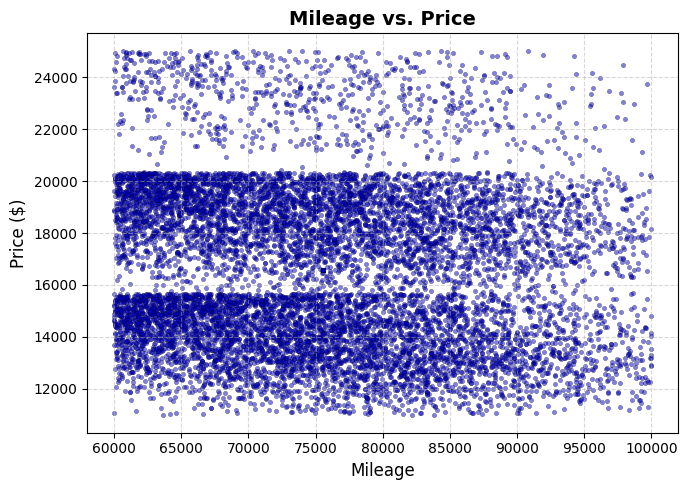

In [ ]:
##scatter plot

import csv
import matplotlib.pyplot as plt

# Initialize lists to store mileage and price data
mileages = []
prices = []

# Open and read the CSV file
with open("cars_cleaned.csv", "r") as file:
    reader = csv.reader(file)
    headers = next(reader)  # Skip header row

    # Find the indexes for mileage and price columns
    for i in range(len(headers)):
        if headers[i].lower() == "mileage":
            mileage_index = i
        if headers[i].lower() == "price":
            price_index = i

    # Collect mileage and price values from each row
    for row in reader:
        try:
            mileage = float(row[mileage_index])
            price = float(row[price_index])
            mileages.append(mileage)
            prices.append(price)
        except ValueError:
            continue  # Skip rows with missing or invalid data

# Create the scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(mileages, prices,
            color='mediumblue',
            alpha=0.5,
            s=10,
            marker='o',
            edgecolors='black',
            linewidth=0.3)

# Add labels, title, and grid
plt.title("Mileage vs. Price", fontsize=14, fontweight='bold')
plt.xlabel("Mileage", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=300)
plt.show()


This scatter plot shows three clear price groups.
1. Vehicles priced above \$20,000
2. Vehicles priced below \$20,000 and above \$16,000
3. Vehicles priced below \$16,000

Within each of these groups, there is a general trend where higher mileage tends to come with a lower price. The pattern isn't perfectly linear, but the overall direction is consistent and price tends to drop as mileage increases, even within each bracket.

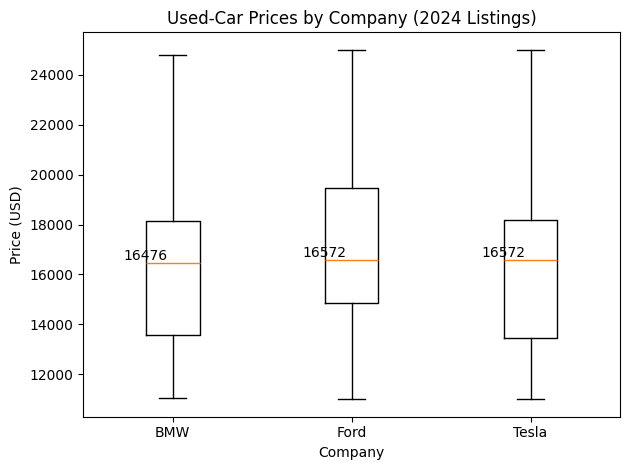

In [ ]:
import csv
import matplotlib.pyplot as plt

# Path to the CSV file
INPUT_FILE = 'cars_cleaned.csv'

# Read data from the CSV
# We'll collect prices in a dict keyed by company name.
company_prices = {}

with open(INPUT_FILE, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)  # read the first line as header names

    # Find which column index corresponds to 'company' and 'price
    company_idx = headers.index('company')
    price_idx = headers.index('price')

    # Process each remaining row
    for row in reader:
        # Skip rows that are too short
        if len(row) <= max(company_idx, price_idx):
            continue

        company = row[company_idx]

        # Convert the price text into a float
        try:
            price = float(row[price_idx])
        except ValueError:
            # If conversion fails for any reason, skip this row
            continue

        # Add the price to our list for this company
        if company not in company_prices:
            company_prices[company] = []
        company_prices[company].append(price)


# Prepare data for the boxplot
# Sort company names so the plot order is consistent
company_labels = sorted(company_prices.keys())

# Gather the price lists in the same order as labels
plot_data = []
for label in company_labels:
    plot_data.append(company_prices[label])


fig, ax = plt.subplots()

# Draw the box-and-whisker plot (once)
boxplot_result = ax.boxplot(plot_data, tick_labels=company_labels)

# Add axis labels and a title
ax.set_xlabel('Company')
ax.set_ylabel('Price (USD)')
ax.set_title('Used-Car Prices by Company (2024 Listings)')

# Annotate the medians
medians = boxplot_result['medians']
for median in medians:
    x_coord = median.get_xdata()[0]
    y_coord = median.get_ydata()[0]
    ax.text(x_coord, y_coord, f'{y_coord:.0f}',
            horizontalalignment='center',
            verticalalignment='bottom')

# Adjust layout and display
plt.tight_layout()
plt.savefig("box_plot.png", dpi=300)
plt.show()


The above box-and-whisker plot shows that the maxiumum and minimum prices for the three brands are similar. The interquartile range (IQR) here is notable. BMW and Tesla, more "premium and upscale brands" have a lower quartile  AND upper quartile when compared with Ford, a more mainstream auto manufacturer. By virtue of this, we can see that even though the median price is almost the same for all three brands, BMW and Tesla take a harder depreciation curve than Ford.

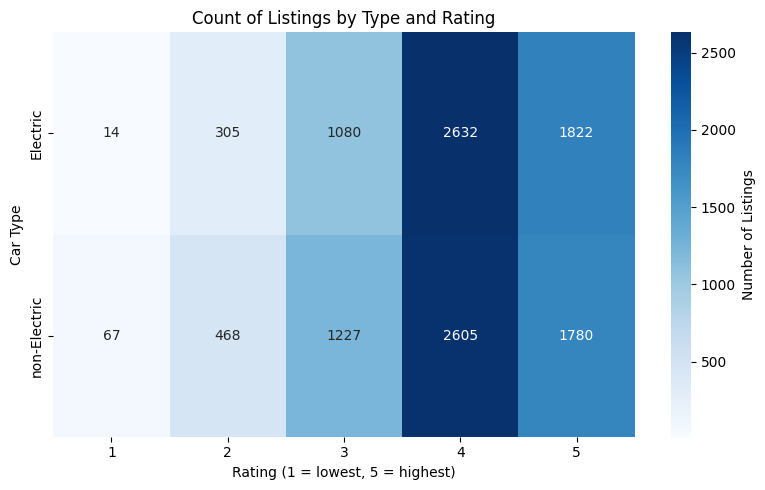

In [ ]:
import csv
import seaborn
import matplotlib.pyplot as plt


# We'll build a dictionary where:
#   key   = (car_type, rating)
#   value = number of listings that match
listing_counts = {}

# We also keep track of the unique types and ratings we see,
# so that we can sort them later for our heatmap axes.
car_type = set()
rating_values = set()


# Read the CSV file row by row
with open('cars_cleaned.csv', mode='r', newline='') as csv_file:
    reader = csv.DictReader(csv_file)

    for row in reader:
        type = row['type']       #  "Electric" or "non-Electric"
        rating_str = row['rating']     #  "4" or "5"

        # Try converting the rating from text to an integer
        try:
            rating = int(rating_str)
        except ValueError:
            # If conversion fails (bad data), skip this row
            continue

        # Remember this type and rating for sorting later
        car_type.add(type)
        rating_values.add(rating)

        # Increment our count for this (type, rating) pair
        key = (type, rating)
        if key not in listing_counts:
            listing_counts[key] = 0
        listing_counts[key] += 1


# Prepare sorted lists for axes
sorted_types   = sorted(car_type)  # ['Electric', 'non-Electric']
sorted_ratings = sorted(rating_values)     # [1, 2, 3, 4, 5]


# Build a nested list/array
# heatmap_data[i][j] is the count for:
#   type   = sorted_types[i]
#   rating = sorted_ratings[j]
heatmap_data = []
for dt in sorted_types:
    row = []
    for rt in sorted_ratings:
        # Get the count if it exists, otherwise use 0
        count = listing_counts.get((dt, rt), 0)
        row.append(count)
    heatmap_data.append(row)

# Plot the heatmap
plt.figure(figsize=(8, 5))

# Create the heatmap
# seaborn.heatmap accepts parameters found here https://seaborn.pydata.org/generated/seaborn.heatmap.html
heatmap_axes = seaborn.heatmap(
    heatmap_data,
    annot=True,          # show numbers in each cell
    fmt='d',             # integer format
    cmap='Blues',        # color scheme
    cbar_kws={'label': 'Number of Listings'}  # label for the colorbar
)

# Label the ticks on each axis
heatmap_axes.set_xticklabels(sorted_ratings)
heatmap_axes.set_yticklabels(sorted_types)

# Add a title and axis labels
plt.title('Count of Listings by Type and Rating')
plt.xlabel('Rating (1 = lowest, 5 = highest)')
plt.ylabel('Car Type')

# Tighten layout so labels don’t overlap
plt.tight_layout()

# Show the final chart
plt.savefig("heatmap.png", dpi=300)
plt.show()


This heatmap shows how car listings are spread across types and customer ratings. Most listings fall in the higher rating range, with a heavy concentration at ratings 4 and 5. That pattern holds for both electric and non-electric vehicles. A sharp dropoff appears below rating 3, and only a small number of listings are rated 1 or 2.

One key reason for the spike at 4 is that we filled in missing ratings using the overall average, which happened to be 4. That reinforced an already strong cluster at that rating. It's also worth noting that people often rate things positively by default but may hesitate to give a perfect score, which may help to explain why 4 is more common than 5.

**Conclusion**

Overall, the dataset reveals three key trends shaping the used car market in 2024. First, prices are fairly consistent across brands and types, with only slight variation. This suggests a competitive market where brand name plays a limited role in setting price. Second, electric vehicles are slightly more affordable than non-electric ones, hinting at broader accessibility or deliberate market positioning. Third, most cars receive high ratings, which reflects strong customer sentiment. Some of that trend may be reinforced by how missing ratings were filled in. Taken together, these patterns suggest a market that is stabilizing in price, opening up to electric options, and shaped by confident, informed buyers.



**Recommendation**

One recommendation is to expand the dataset to include a broader range of data. This could involve adding vehicles from additional years, such as 2020 to 2024, to identify trends over time. Including more companies , beyond the current focus on mainstream or premium brands would also allow for a more comprehensive comparison across different market segments. Finally, instead of filling in missing values with the mean or mode, it may be better to leave blanks or use more advanced methods. Filling in missing data with averages likely skewed some results and may have introduced artificial trends.

# New Section